# EDA 14: Genome Instability Signatures

## Purpose

`14_OmicsGlobalSignatures.csv` reports whole-genome instability scores — MSI (microsatellite
instability), CIN (chromosomal instability), ploidy, aneuploidy, loss-of-heterozygosity fraction,
and whole-genome doubling (WGD) — model-level summaries, not per-gene measurements. Like
metabolomics and miRNA, `docs/PROJECT_ARCHITECTURE.md` §6 expects this layer to fail the
gene-addressable (A1) criterion. It is also the source of one of the **six uncited thresholds**
`docs/plan/CONSTRAINTS.md` §3 names directly: the `MSIScore >= 20` MSI-high cutoff.

**Source, release, grain:** DepMap whole-genome signature scores, only available for WGS-sequenced
lines. 3,021 rows (multiple entries per model before filtering), keyed by `ModelID`.

## Questions this notebook must answer

1. After filtering to the default entry per model, how much missingness remains in each of the six
   scores — and is it structural (WGS-only) rather than random?
2. What do cancer-line values for each score look like relative to a diploid baseline?
3. Are CIN and Aneuploidy redundant — worth carrying both, or is one enough?
4. What fraction of the primary spine has WGS coverage, and is it lineage-biased?
5. Does the standard clinical `MSIScore >= 20` cutoff produce a usable binary split here?

**Interpretation rule:** a score is `measured` only for WGS-sequenced lines; everything else is
`not_assayed` for this layer entirely, not a biological zero — a `NaN` CIN score does not mean
"chromosomally stable," it means "never checked.\"

## Column dictionary

| Column | Meaning | Notes |
|---|---|---|
| `ModelID` | join key | filter `IsDefaultEntryForModel == 'Yes'` first |
| `MSIScore` | microsatellite instability score | fully populated even without WGS; clinical cutoff `>=20` = MSI-high |
| `LoHFraction` | fraction of genome with loss of heterozygosity | WGS-only |
| `WGD` | whole-genome doubling (binary) | WGS-only |
| `CIN` | chromosomal instability score | WGS-only |
| `Ploidy` | average chromosome copy count | WGS-only |
| `Aneuploidy` | degree of chromosome-number abnormality | WGS-only; correlated with CIN |

## 1. Basic data contract, default-entry filtering, and missingness

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
NON_GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'non_gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

All rows: 3021  |  Default-entry rows: 1955


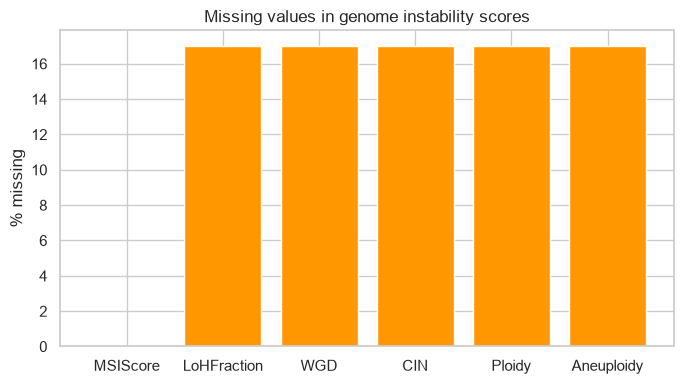

In [2]:
df = pd.read_csv(NON_GENE_EXPRESSION / '14_OmicsGlobalSignatures.csv').drop(columns=['Unnamed: 0'], errors='ignore')
df_def = df[df['IsDefaultEntryForModel'] == 'Yes'].copy()
print(f"All rows: {len(df)}  |  Default-entry rows: {len(df_def)}")

score_cols = ['MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']
pct_missing = df_def[score_cols].isnull().mean() * 100
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(score_cols, pct_missing, color=['#4CAF50' if v < 5 else '#FF9800' for v in pct_missing])
ax.set_ylabel('% missing'); ax.set_title('Missing values in genome instability scores')
plt.tight_layout(); plt.show()

### Why this EDA check matters

`MSIScore` is expected to be nearly complete while the WGS-only scores show a much larger, uniform
gap — confirming the missingness here is structural (no WGS run for that line) rather than
random. This is exactly the `not_assayed` case, not `measured_absent`.

## 2. Score distributions against a cancer-panel baseline

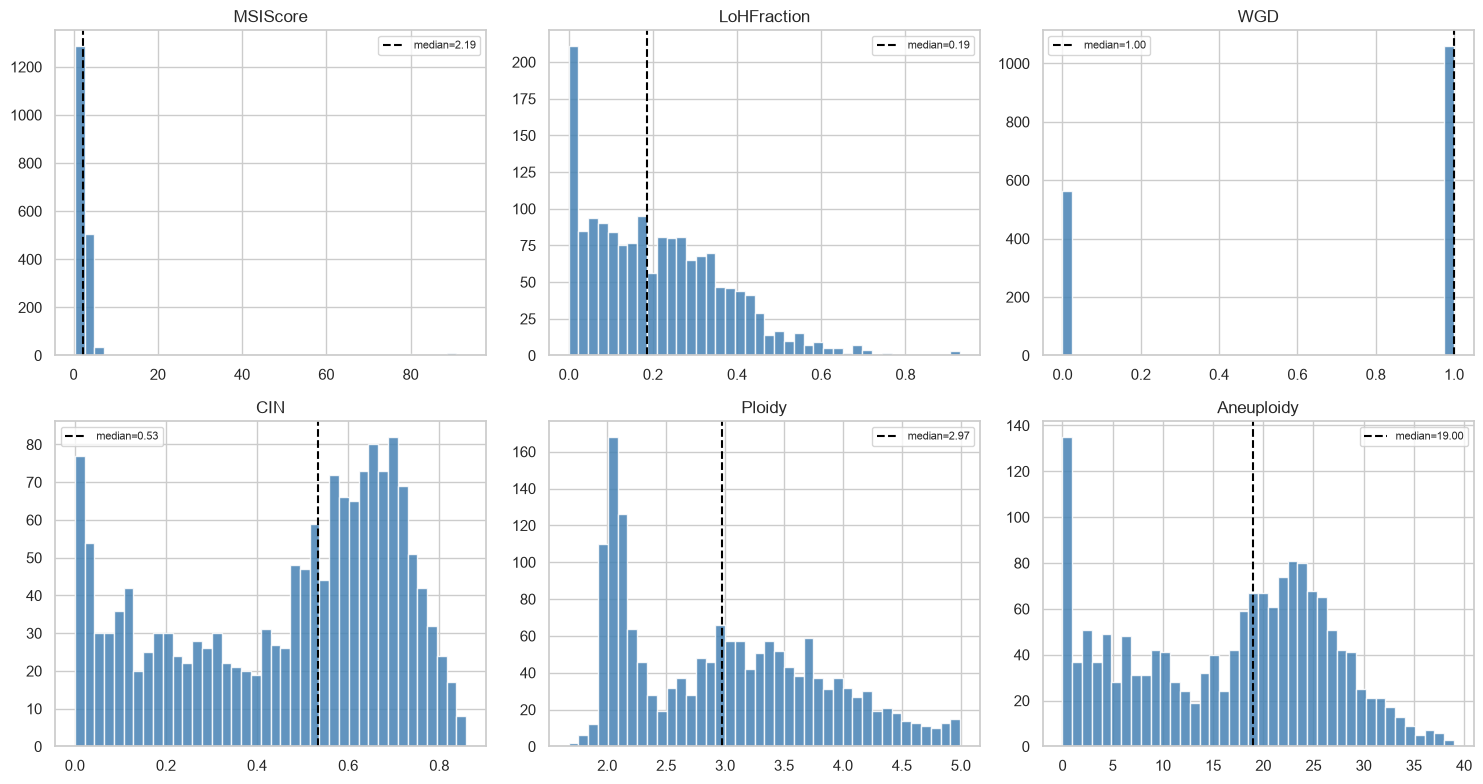

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, score_cols):
    data = df_def[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', label=f'median={data.median():.2f}')
    ax.set_title(col); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Why this EDA check matters

These are cancer cell lines, so medians sit above a healthy-diploid baseline by design — reading
any individual line's score against a normal-tissue anchor would misrepresent what "high" means
here. The cancer-panel median computed above is the correct reference point.

## 3. CIN vs. Aneuploidy redundancy

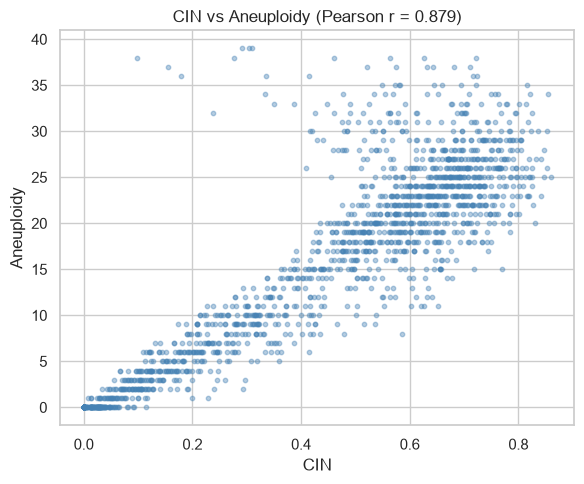

In [4]:
pair = df_def[['CIN', 'Aneuploidy']].dropna()
r, p = stats.pearsonr(pair['CIN'], pair['Aneuploidy'])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pair['CIN'], pair['Aneuploidy'], alpha=0.4, s=10, color='steelblue')
ax.set_xlabel('CIN'); ax.set_ylabel('Aneuploidy')
ax.set_title(f'CIN vs Aneuploidy (Pearson r = {r:.3f})')
plt.tight_layout(); plt.show()

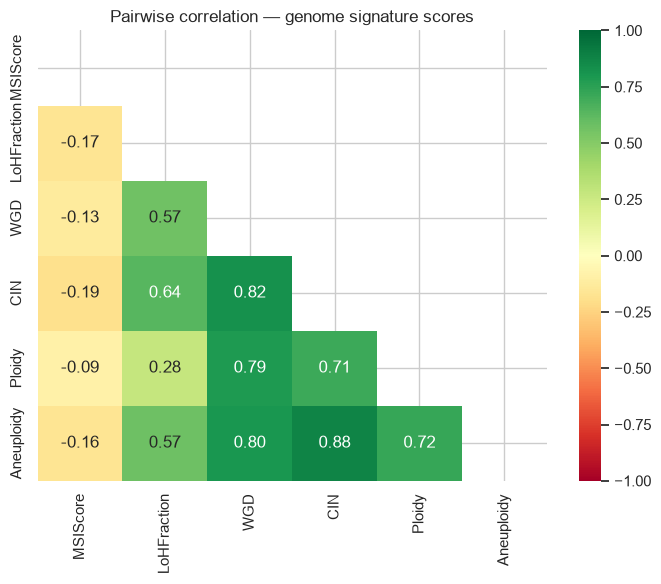

In [5]:
corr = df_def[score_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1, ax=ax, mask=mask)
ax.set_title('Pairwise correlation — genome signature scores')
plt.tight_layout(); plt.show()

### Why this EDA check matters

A strong CIN-Aneuploidy correlation means carrying both as independent context features would
double-count essentially the same underlying instability — same principle as the correlation
discount `docs/PROJECT_ARCHITECTURE.md` §5(d) applies to genes, here applied to feature selection
among candidate context signatures.

## 4. Coverage and the MSI-high clinical cutoff

In [6]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
wgs_models = set(df_def.dropna(subset=['CIN'])['ModelID'])
sig_models = set(df_def['ModelID'].dropna())
covered = df9[df9['DepMap_ID'].isin(sig_models)]
wgs_covered = df9[df9['DepMap_ID'].isin(wgs_models)]

total_per = df9['lineage'].value_counts()
wgs_per = wgs_covered['lineage'].value_counts()
wgs_pct = (wgs_per / total_per * 100).dropna().sort_values()

print(f"Models with MSIScore                 : {len(sig_models)}")
print(f"Models with full WGS signature set   : {len(wgs_models)} ({len(wgs_models)/df9['DepMap_ID'].nunique():.1%} of primary spine)")
print()
msi_high = df_def['MSIScore'] >= 20
print(f"MSI-high (MSIScore >= 20)            : {int(msi_high.sum())} of {df_def['MSIScore'].notna().sum()} scored lines ({msi_high.mean():.1%})")

Models with MSIScore                 : 1955
Models with full WGS signature set   : 1622 (88.2% of primary spine)

MSI-high (MSIScore >= 20)            : 112 of 1955 scored lines (5.7%)


### Why this EDA check matters

This is the direct evidence base for the `MSIScore >= 20` threshold `docs/plan/CONSTRAINTS.md` §3
lists as uncited — the resulting MSI-high fraction here is what a sensitivity sweep (per
`CONSTRAINTS.md`'s resolution: adopt as a documented default, then sweep) would test against. The
WGS-only coverage fraction is the A2 admission-gate evidence for the four instability scores that
require a full genome sequence, separate from `MSIScore` which is far more complete.

## Decisions carried into the next notebooks

1. **Filter to `IsDefaultEntryForModel == 'Yes'` before any per-model use.**
2. `MSIScore` is broadly usable; `LoHFraction`/`WGD`/`CIN`/`Ploidy`/`Aneuploidy` are `not_assayed`
   for any non-WGS line — a structural gap, not random missingness.
3. **CIN and Aneuploidy are redundant (§3)** — carrying one is sufficient signal; document this in
   `docs/plan/METHOD_DECISION.md` if both are proposed as context features.
4. **`MSIScore >= 20` is the documented default for the MSI-high threshold** — the resulting
   split fraction here is the number to re-check under `CONSTRAINTS.md`'s required sensitivity
   sweep, not a new, independently-chosen cutoff.
5. **This layer has no per-gene mapping** — same expected A1 verdict as metabolomics and miRNA:
   model-level context/filter, not a scored layer, pending `docs/plan/METHOD_DECISION.md`.